In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings


In [2]:
df = pd.read_csv('phishing_email.csv')

In [7]:
df.head(10)

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0
5,hpl nom may 31 2001 see attached file hplno 53...,0
6,9760 tried get fancy address came back forward...,0
7,hpl noms february 15 2000 see attached file hp...,0
8,fw pooling contract template original message ...,0
9,hpl nom march 28 2000 see attached file hplo 3...,0


In [8]:
df.tail(10)

,text_combined,label
82476,usaawebservices benwestbrooklawfirmcom usaa se...,1
82477,support michaelhardymypostofficecouk monkeyorg...,1
82478,netlflx cool390rnatlikadeliycom dear customer ...,1
82479,wetransfer no_replywetransfercom test transfer...,1
82480,monkeyorg support inboxinboxorg queued message...,1
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1
82485,fastway infofastwaycoza_infofastwaycoza_infofa...,1


In [10]:
df.isnull().sum()

text_combined    0
label            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(408)

In [13]:
df = df.drop_duplicates(keep = 'first')

In [14]:
df.shape

(82078, 2)

In [15]:
df['label'].value_counts()

label
1    42845
0    39233
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x20fa6210050>,
 [Text(-0.0759779853362729, 1.0973729292014822, 'ham'),
  Text(0.07597768882052051, -1.0973729497310805, 'spam')],
 [Text(-0.04144253745614885, 0.5985670522917175, '52.20'),
  Text(0.04144237572028391, -0.5985670634896801, '47.80')])

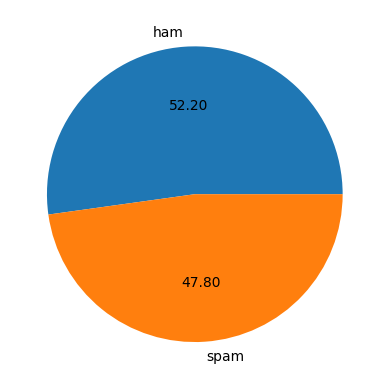

In [19]:
plt.pie(df['label'].value_counts(), labels=['ham','spam'],autopct = "%0.2f")

In [20]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
1    42845
0    39233
Name: count, dtype: int64
label
1    52.200346
0    47.799654
Name: proportion, dtype: float64


In [21]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [24]:
df['num_characters'] = df['text_combined'].apply(len)

In [26]:
from nltk.tokenize import word_tokenize

df['num_words'] = df['text_combined'].apply(lambda x: len(word_tokenize(x)))

In [27]:
from nltk.tokenize import sent_tokenize

df['num_sentences'] = df['text_combined'].apply(lambda x: len(sent_tokenize(x)))

In [32]:
df[['text_combined', 'num_characters', 'num_words', 'num_sentences','label']].tail(10)

,text_combined,num_characters,num_words,num_sentences,label
82476,usaawebservices benwestbrooklawfirmcom usaa se...,1078,148,1,1
82477,support michaelhardymypostofficecouk monkeyorg...,200,23,1,1
82478,netlflx cool390rnatlikadeliycom dear customer ...,366,37,1,1
82479,wetransfer no_replywetransfercom test transfer...,820,97,1,1
82480,monkeyorg support inboxinboxorg queued message...,268,35,1,1
82481,info advantageapartmentscom infoadvantageapart...,1735,238,1,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,188,22,1,1
82483,help center infohelpcentercoza_infohelpcenterc...,948,108,1,1
82484,metamask infosofamekarcom verify metamask wall...,376,50,1,1
82485,fastway infofastwaycoza_infofastwaycoza_infofa...,819,112,1,1


In [33]:
df[['text_combined', 'num_characters', 'num_words', 'num_sentences','label']].head(10)

,text_combined,num_characters,num_words,num_sentences,label
0,hpl nom may 25 2001 see attached file hplno 52...,65,14,1,0
1,nom actual vols 24 th forwarded sabrae zajac h...,1071,208,1,0
2,enron actuals march 30 april 1 201 estimated a...,148,28,1,0
3,hpl nom may 30 2001 see attached file hplno 53...,65,14,1,0
4,hpl nom june 1 2001 see attached file hplno 60...,65,14,1,0
5,hpl nom may 31 2001 see attached file hplno 53...,65,14,1,0
6,9760 tried get fancy address came back forward...,313,57,1,0
7,hpl noms february 15 2000 see attached file hp...,69,14,1,0
8,fw pooling contract template original message ...,215,34,1,0
9,hpl nom march 28 2000 see attached file hplo 3...,65,14,1,0


In [35]:
df.groupby('label')['text_combined'].head()

0       hpl nom may 25 2001 see attached file hplno 52...
1       nom actual vols 24 th forwarded sabrae zajac h...
2       enron actuals march 30 april 1 201 estimated a...
3       hpl nom may 30 2001 see attached file hplno 53...
4       hpl nom june 1 2001 see attached file hplno 60...
3503    link dwl g 510 802 11 g wireless pci lan adapt...
3504    indemand payperview movies sports wed 15 sep 2...
3505    want lose 19 weight try adipren hello special ...
3506    cialis xanax valium viagra low price prescript...
3507    pre order see image click indelible backscatte...
Name: text_combined, dtype: object

In [36]:
df.groupby('label')[['num_characters','num_words','num_sentences']].mean()

,num_characters,num_words,num_sentences
label,,,
0,1541.456147,203.703897,1.000000
1,1060.692520,121.350239,0.999977


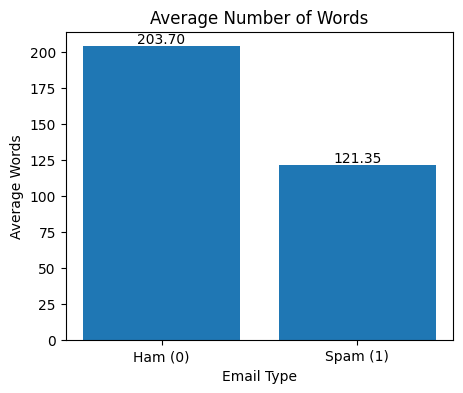

In [39]:


avg_words = df.groupby('label')['num_words'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Ham (0)', 'Spam (1)'], avg_words)
plt.title("Average Number of Words")
plt.xlabel("Email Type")
plt.ylabel("Average Words")

for i, v in enumerate(avg_words):
    plt.text(i, v+2, f"{v:.2f}", ha='center')

plt.show()

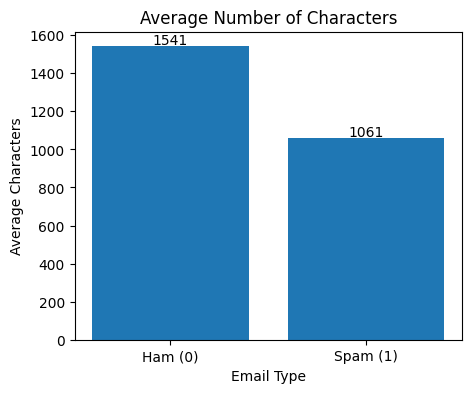

In [40]:
avg_char = df.groupby('label')['num_characters'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Ham (0)', 'Spam (1)'], avg_char)
plt.title("Average Number of Characters")
plt.xlabel("Email Type")
plt.ylabel("Average Characters")

for i, v in enumerate(avg_char):
    plt.text(i, v+10, f"{v:.0f}", ha='center')

plt.show()

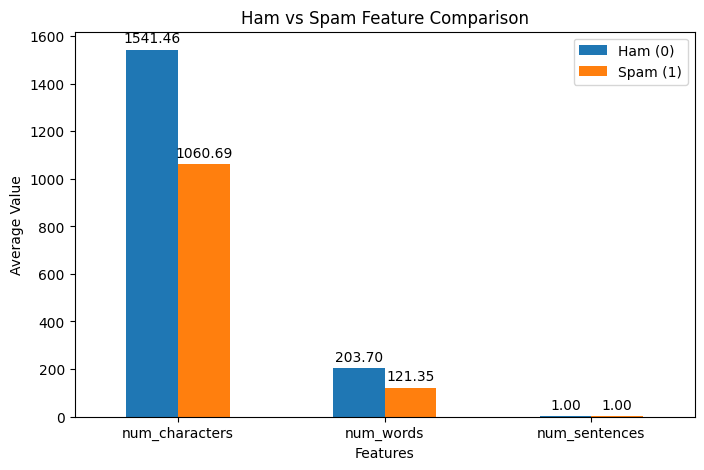

In [42]:
import matplotlib.pyplot as plt

avg = df.groupby('label')[['num_characters','num_words','num_sentences']].mean()

ax = avg.T.plot(kind='bar', figsize=(8,5))

plt.title("Ham vs Spam Feature Comparison")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(['Ham (0)', 'Spam (1)'])

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

## NLP PREPROCESSING


In [45]:
df['text_combined'] = df['text_combined'].str.lower()

In [47]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

In [48]:
def transform_text(text):
    text = text.lower()

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalnum()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if word not in string.punctuation]
    tokens = [ps.stem(word) for word in tokens]
    text = " ".join(tokens)

    return text

In [49]:
df['text_combined'] = df['text_combined'].apply(transform_text)

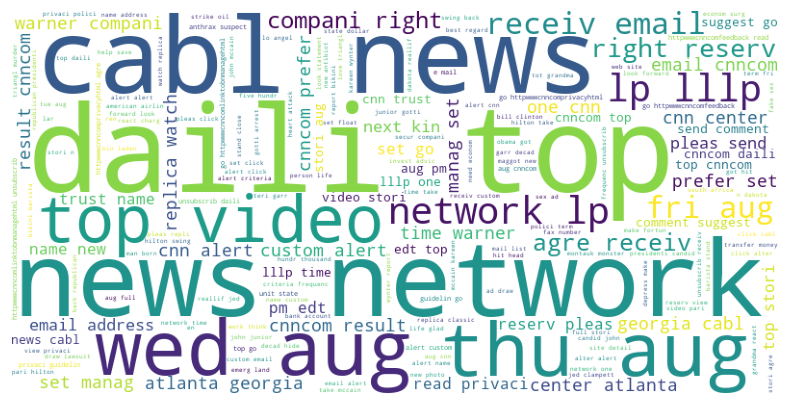

In [50]:
from wordcloud import WordCloud

spam_wc = WordCloud(width=800,height=400,background_color='white').generate(
    ' '.join(df[df['label']==1]['text_combined'])
)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

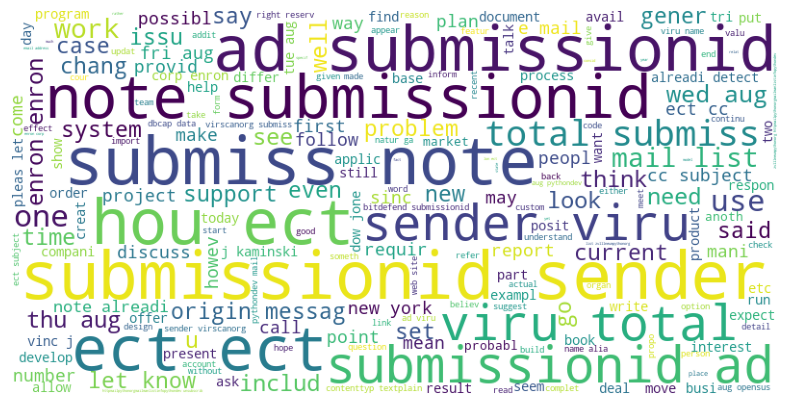

In [51]:
ham_wc = WordCloud(width=800,height=400,background_color='white').generate(
    ' '.join(df[df['label']==0]['text_combined'])
)

plt.figure(figsize=(10,5))
plt.imshow(ham_wc)
plt.axis("off")
plt.show()

In [52]:
from collections import Counter

spam_words = []

for msg in df[df['label']==1]['text_combined']:
    spam_words.extend(msg.split())

Counter(spam_words).most_common(30)

[('2008', 32008),
 ('10', 29417),
 ('email', 28049),
 ('aug', 28035),
 ('top', 23185),
 ('compani', 21638),
 ('1', 20182),
 ('go', 18652),
 ('account', 18623),
 ('pleas', 18557),
 ('money', 17804),
 ('receiv', 16764),
 ('2', 16687),
 ('3', 16298),
 ('one', 16153),
 ('news', 15928),
 ('time', 15712),
 ('us', 15451),
 ('inform', 15280),
 ('get', 14874),
 ('5', 14738),
 ('cnncom', 14533),
 ('name', 14082),
 ('alert', 13541),
 ('bank', 12955),
 ('secur', 12721),
 ('cnn', 12673),
 ('busi', 12383),
 ('daili', 12242),
 ('make', 11847)]

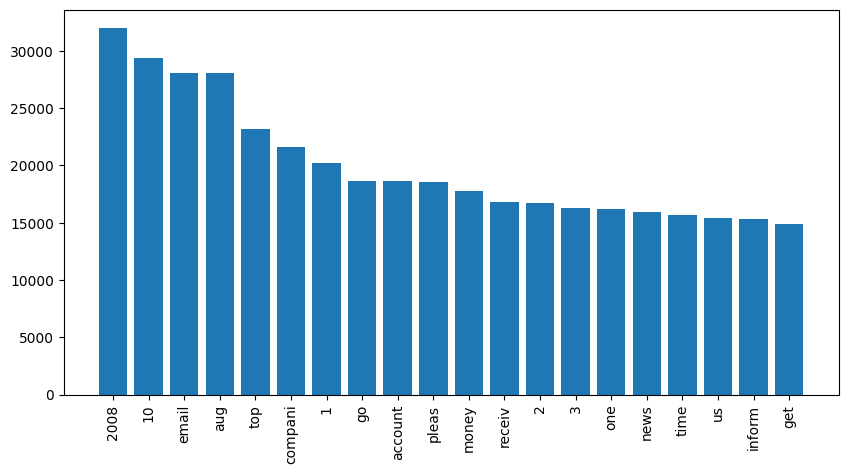

In [53]:
common = Counter(spam_words).most_common(20)

words = [i[0] for i in common]
counts = [i[1] for i in common]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.show()

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['text_combined']).toarray()

y = df['label']

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['text_combined'])
y = df['label']

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_pred = mnb.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9610745614035088
Precision: 0.9753056820906257
Recall   : 0.9494690162212627
F1 Score : 0.9622139435870144


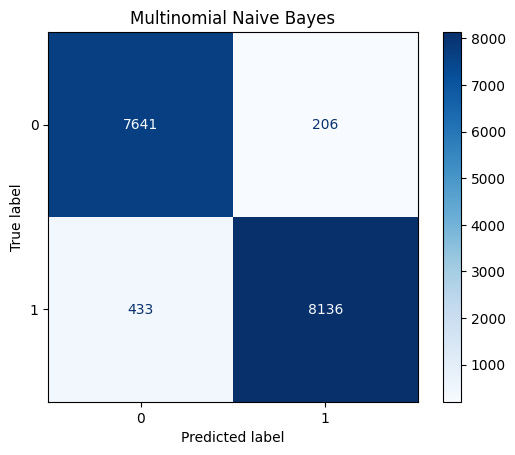

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Multinomial Naive Bayes")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7847
           1       0.98      0.95      0.96      8569

    accuracy                           0.96     16416
   macro avg       0.96      0.96      0.96     16416
weighted avg       0.96      0.96      0.96     16416



In [66]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9814205653021443
Precision: 0.9790169255738466
Recall   : 0.9855292332827634
F1 Score : 0.9822622855481244


In [67]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.9854410331384016
Precision: 0.9843023255813953
Recall   : 0.9878632279145758
F1 Score : 0.9860795620012813


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9860501949317739
Precision: 0.9885192127460168
Recall   : 0.9847123351616291
F1 Score : 0.9866121017246419


In [69]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.9819078947368421
Precision: 0.9767173812816966
Recall   : 0.9889135254988913
F1 Score : 0.9827776167004929
